# Visualizations

Five figures for the presentation and report. Reads the saved outputs from the three production notebooks. Nothing is recomputed.

| Figure | Section | What it shows |
|---|---|---|
| Score resolution | ML | 25 distinct scores against one per loan |
| Floor sweep | LP | What each equity floor costs |
| The 2x3 interaction | LP | A better score only pays if the rule chases return |
| Return distributions | Simulation | Where each portfolio lands across 10,000 years |
| Edge under stress | Simulation | The model's advantage grows in bad years |

## Style choices

- **Purple and orange** for the two scores, held constant across every figure so the reader learns the code once.
- **Line style carries the same information as color.** Solid for one, dashed for the other. The figures stay readable in grayscale, on a bad projector, and for anyone with color vision deficiency.
- **`tableau-colorblind10`** for everything else.
- Every figure gets a title, axis labels with units, and a legend where more than one thing is plotted.

pool          : (409857, 21)
sim returns   : (10000, 6)
portfolios    : 6 in summary
floor sweep   : 18 runs
grid          : 36 rows

--- what the portfolio summary holds ---
  rule-based / risk-sort           real $2,272.0M
  rule-based / greedy-return       real $2,723.8M
  CatBoost / risk-sort             real $2,190.4M
  CatBoost / greedy-return         real $2,806.9M
  rule-based / LP                  real $2,707.0M
  CatBoost / LP                    real $2,778.8M

--- colors ---


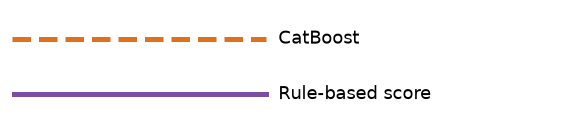

In [1]:
import polars as pl
import numpy as np
import json
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, PercentFormatter
from pathlib import Path

PROC = Path("../data/processed")
FIGS = Path("../figures")
FIGS.mkdir(exist_ok=True)

plt.style.use("tableau-colorblind10")
plt.rcParams.update({
    "figure.dpi": 120,          # screen
    "savefig.dpi": 300,         # print and slides
    "savefig.bbox": "tight",
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "legend.frameon": False,
})

# --- the two scores, locked for every figure ---
PURPLE = "#7B4EA3"      # rule-based
ORANGE = "#E1701A"      # CatBoost

SCORE = {
    "rule": {"color": PURPLE, "ls": "-",  "label": "Rule-based score"},
    "cat":  {"color": ORANGE, "ls": "--", "label": "CatBoost"},
}

def money(x, _=None):
    """$2,806.9M -> readable axis labels."""
    return f"${x:,.0f}M"

def save(fig, name):
    """Write both formats: png for slides, pdf for the report."""
    for ext in ("png", "pdf"):
        fig.savefig(FIGS / f"{name}.{ext}")
    print(f"saved {name}.png and {name}.pdf")

# ---------------- load everything ----------------
pool = pl.read_parquet(PROC / "prod_pool.parquet")
sim_returns = pl.read_parquet(PROC / "prod_sim_returns.parquet")
port_summary = json.loads((PROC / "prod_portfolios_summary.json").read_text())
sim_summary = json.loads((PROC / "prod_sim_summary.json").read_text())

print(f"pool          : {pool.shape}")
print(f"sim returns   : {sim_returns.shape}")
print(f"portfolios    : {len(port_summary['portfolios'])} in summary")
print(f"floor sweep   : {len(port_summary['floor_sweep']['runs'])} runs")
print(f"grid          : {len(sim_summary['sensitivity_grid'])} rows")

print("\n--- what the portfolio summary holds ---")
for p in port_summary["portfolios"]:
    print(f"  {p['portfolio']:32} real ${p['real_M']:,.1f}M")

print("\n--- colors ---")
fig, ax = plt.subplots(figsize=(6, 1.2))
for i, (k, s) in enumerate(SCORE.items()):
    ax.plot([0, 1], [i, i], color=s["color"], ls=s["ls"], lw=3, label=s["label"])
    ax.text(1.05, i, s["label"], va="center")
ax.set_xlim(0, 2.2)
ax.set_ylim(-0.5, 1.5)
ax.axis("off")
plt.show()

## Figure 1: score resolution

The same 409,857 loans, scored two ways.

**Top panel: the rule-based lookup.** Credit grade crossed with LTV band gives 30 buckets, 6 of which fell back for thin data. Every loan in a bucket gets that bucket's historical default rate, so the entire pool collapses onto 25 values.

**Bottom panel: CatBoost.** One score per loan.

**Why log scale.** Predicted default probability runs from 0.02% to 59%, more than three orders of magnitude, and most loans sit under 5%. On a linear axis everything piles into the left edge and the spikes are unreadable. Ticks are labeled as percentages rather than powers of ten.

**The point.** Both scorers are calibrated and both get the pool average right. The difference is resolution: the lookup cannot tell two loans in the same bucket apart, and the optimizer has to rank individual loans against each other.

saved fig1_score_resolution.png and fig1_score_resolution.pdf


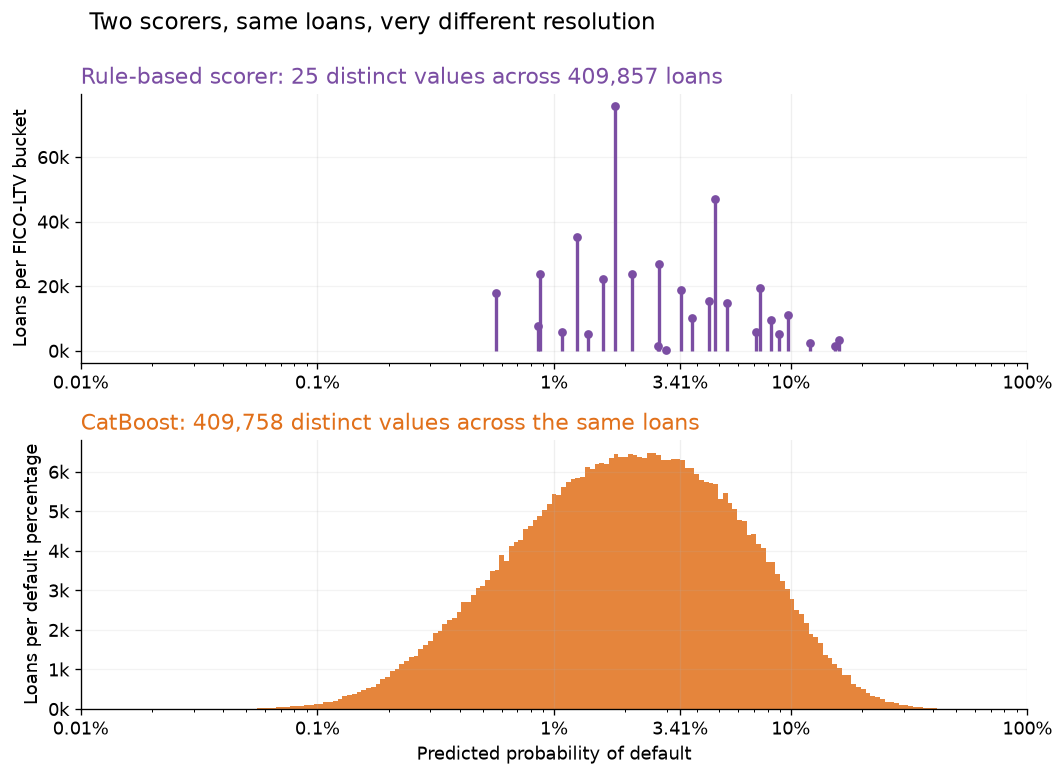

rule-based scorer : 25 distinct values, 0.57% to 15.92%
CatBoost          : 409,758 distinct values, 0.0234% to 58.53%

mean predicted, rule-based scorer : 3.4043%
mean predicted, CatBoost          : 3.4016%
actual default rate               : 3.4095%


In [5]:
s_rule = pool["score_rule"].to_numpy()
s_cat = pool["pd"].to_numpy()
actual_rate = pool["default_flag"].mean()

n_rule = len(np.unique(s_rule))
n_cat = len(np.unique(s_cat))

fig, axes = plt.subplots(2, 1, figsize=(9, 6.5), sharex=True)

bins = np.logspace(np.log10(1e-4), np.log10(1.0), 200)

# --- top: the rule-based scorer, every loan lands on one of 25 values ---
ax = axes[0]
vals, counts = np.unique(s_rule, return_counts=True)
ax.vlines(vals, 0, counts, color=SCORE["rule"]["color"], lw=2.0)
ax.scatter(vals, counts, color=SCORE["rule"]["color"], s=18, zorder=3)
ax.set_ylabel("Loans per FICO-LTV bucket")
ax.set_title(f"Rule-based scorer: {n_rule} distinct values across {len(pool):,} loans",
             loc="left", color=SCORE["rule"]["color"])
ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v/1000:,.0f}k"))
ax.tick_params(labelbottom=True)          # keep the axis visible on both panels

# --- bottom: CatBoost, near enough one value per loan ---
ax = axes[1]
ax.hist(s_cat, bins=bins, color=SCORE["cat"]["color"], edgecolor="none", alpha=0.85)
ax.set_ylabel("Loans per default percentage")
ax.set_xlabel("Predicted probability of default")
ax.set_title(f"CatBoost: {n_cat:,} distinct values across the same loans",
             loc="left", color=SCORE["cat"]["color"])
ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v/1000:,.0f}k"))

# --- shared x-axis, with the book's actual default rate as a real tick ---
ax.set_xscale("log")
ax.set_xlim(1e-4, 1.0)
ticks = [0.0001, 0.001, 0.01, actual_rate, 0.1, 1.0]
labels = ["0.01%", "0.1%", "1%", f"{actual_rate*100:.2f}%", "10%", "100%"]
for a in axes:
    a.set_xticks(ticks)
    a.set_xticklabels(labels)
    a.grid(axis="x", alpha=0.2, which="major")
    a.grid(axis="y", alpha=0.15)

fig.suptitle("Two scorers, same loans, very different resolution",
             y=0.99, fontsize=14, ha="left", x=0.09)
plt.tight_layout()
save(fig, "fig1_score_resolution")
plt.show()

print(f"rule-based scorer : {n_rule} distinct values, "
      f"{s_rule.min()*100:.2f}% to {s_rule.max()*100:.2f}%")
print(f"CatBoost          : {n_cat:,} distinct values, "
      f"{s_cat.min()*100:.4f}% to {s_cat.max()*100:.2f}%")
print(f"\nmean predicted, rule-based scorer : {s_rule.mean()*100:.4f}%")
print(f"mean predicted, CatBoost          : {s_cat.mean()*100:.4f}%")
print(f"actual default rate               : {actual_rate*100:.4f}%")

In [3]:
s_cat = pool["pd"].to_numpy()

print(f"distinct values : {len(np.unique(s_cat)):,} of {len(s_cat):,} loans")
print(f"range           : {s_cat.min():.10f} to {s_cat.max():.10f}")

print("\n--- first 10 sorted values, full precision ---")
for v in np.sort(s_cat)[:10]:
    print(f"  {v:.15f}")

print("\n--- 10 values near the middle ---")
mid = len(s_cat) // 2
for v in np.sort(s_cat)[mid:mid + 10]:
    print(f"  {v:.15f}")

print("\n--- how close together are neighboring scores ---")
gaps = np.diff(np.unique(s_cat))
print(f"  smallest gap : {gaps.min():.15f}")
print(f"  median gap   : {np.median(gaps):.15f}")
print(f"  largest gap  : {gaps.max():.15f}")

print("\n--- how many loans share a score at each rounding level ---")
for places in [2, 3, 4, 5, 6]:
    n = len(np.unique(np.round(s_cat, places)))
    print(f"  rounded to {places} places : {n:>7,} distinct values")

distinct values : 409,758 of 409,857 loans
range           : 0.0002344192 to 0.5853205884

--- first 10 sorted values, full precision ---
  0.000234419218818
  0.000268929033527
  0.000289205252930
  0.000300944190671
  0.000318222901437
  0.000321851915437
  0.000326619268142
  0.000326836518925
  0.000362033545722
  0.000363222974227

--- 10 values near the middle ---
  0.020954444301621
  0.020954700657698
  0.020954785267858
  0.020954815424491
  0.020954970998448
  0.020955015667642
  0.020955201608512
  0.020955213471929
  0.020955217940575
  0.020955220010311

--- how close together are neighboring scores ---
  smallest gap : 0.000000000000039
  median gap   : 0.000000121241674
  largest gap  : 0.024286439139116

--- how many loans share a score at each rounding level ---
  rounded to 2 places :      57 distinct values
  rounded to 3 places :     429 distinct values
  rounded to 4 places :   3,109 distinct values
  rounded to 5 places :  20,137 distinct values
  rounded to 6 pla

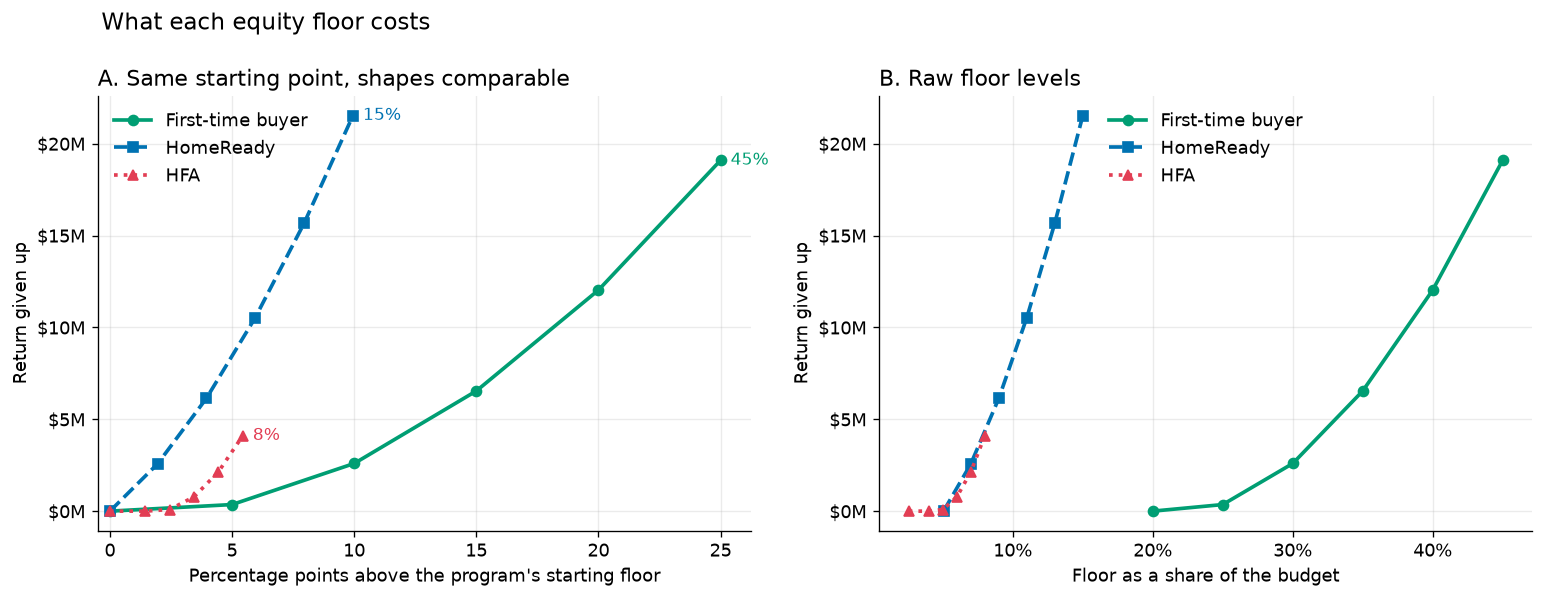

--- the underlying numbers ---
  First-time buyer   20.00% $0.0M   25.00% $0.4M   30.00% $2.6M   35.00% $6.5M   40.00% $12.0M   45.00% $19.1M
  HomeReady          5.05% $0.0M   7.00% $2.6M   9.00% $6.1M   11.00% $10.5M   13.00% $15.7M   15.00% $21.5M
  HFA                2.56% $0.0M   4.00% $0.0M   5.00% $0.1M   6.00% $0.8M   7.00% $2.1M   8.00% $4.1M


In [13]:
sweep = pl.DataFrame(port_summary["floor_sweep"]["runs"])

PROGRAM = {
    "first_time": {"label": "First-time buyer", "color": "#009E73", "ls": "-",  "marker": "o"},
    "homeready":  {"label": "HomeReady",        "color": "#0072B2", "ls": "--", "marker": "s"},
    "hfa":        {"label": "HFA",              "color": "#E23E54", "ls": ":",  "marker": "^"},
}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ---------------- version A: shared axis, points above base ----------------
ax = axes[0]
for key, s in PROGRAM.items():
    d = sweep.filter(pl.col("floor") == key).sort("setting")
    base = d["setting"][0]
    x = (d["setting"].to_numpy() - base) * 100
    y = d["cost_M"].to_numpy()
    ax.plot(x, y, color=s["color"], ls=s["ls"], marker=s["marker"],
            lw=2.2, ms=6, label=s["label"])
    ax.annotate(f"{d['setting'][-1]*100:.0f}%",
                xy=(x[-1], y[-1]), xytext=(6, 0), textcoords="offset points",
                color=s["color"], va="center", fontsize=10)

ax.set_xlabel("Percentage points above the program's starting floor")
ax.set_ylabel("Return given up")
ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"${v:,.0f}M"))
ax.set_title("A. Same starting point, shapes comparable", loc="left")
ax.legend()
ax.set_xlim(left=-0.5)

# ---------------- version B: raw floor levels ----------------
ax = axes[1]
for key, s in PROGRAM.items():
    d = sweep.filter(pl.col("floor") == key).sort("setting")
    x = d["setting"].to_numpy() * 100
    y = d["cost_M"].to_numpy()
    ax.plot(x, y, color=s["color"], ls=s["ls"], marker=s["marker"],
            lw=2.2, ms=6, label=s["label"])

ax.set_xlabel("Floor as a share of the budget")
ax.set_ylabel("Return given up")
ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"${v:,.0f}M"))
ax.xaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:.0f}%"))
ax.set_title("B. Raw floor levels", loc="left")
ax.legend()

fig.suptitle("What each equity floor costs", y=0.99, fontsize=14, ha="left", x=0.07)
plt.tight_layout()
plt.show()

print("--- the underlying numbers ---")
for key, s in PROGRAM.items():
    d = sweep.filter(pl.col("floor") == key).sort("setting")
    pairs = "   ".join(f"{r['setting']*100:.2f}% ${r['cost_M']:.1f}M"
                       for r in d.iter_rows(named=True))
    print(f"  {s['label']:18} {pairs}")

## Two views of the same sweep

Same 18 runs, two ways of reading them.

**A: shapes comparable.** All three curves start at zero, so the x-axis measures how far each floor was pushed above its own starting point. This answers how expensive it is to push a program harder, and it makes the three shapes directly comparable. HomeReady climbs steepest, HFA stays cheapest, first-time rises slowest but runs furthest.

**B: raw floor levels.** The x-axis is the floor itself, as a share of the budget. This answers what a floor at a given level would actually cost, which is the version you would use to defend a specific policy number.

Different questions, same data. Pick the one that matches the claim being made.

In [7]:
port = pl.read_parquet(PROC / "prod_portfolios.parquet")

x = port["x_cat_lp"].to_numpy()
upb = port["ORIG_UPB"].to_numpy()
funded_mask = x > 1e-6
budget_dollars = (x * upb).sum()

print(f"portfolio: CatBoost / LP")
print(f"  loans funded (full or partial) : {funded_mask.sum():,}")
print(f"  dollars funded                 : ${budget_dollars/1e9:,.3f}B")

print(f"\n{'program':16} {'loans':>10} {'% of loans':>12} "
      f"{'$M':>10} {'% of dollars':>14} {'pool % loans':>14}")
print("-" * 80)

for flag, label in [("is_first_time", "First-time"),
                    ("is_homeready", "HomeReady"),
                    ("is_hfa", "HFA")]:
    f = port[flag].to_numpy() == 1

    # loan count: how many funded loans carry the flag
    n_flag = (funded_mask & f).sum()
    pct_loans = n_flag / funded_mask.sum()

    # dollars: weighted by how much of each loan we funded
    d_flag = (x[f] * upb[f]).sum()
    pct_dollars = d_flag / budget_dollars

    # what share of the whole pool carries the flag, by count
    pool_pct = f.sum() / len(port)

    print(f"{label:16} {n_flag:>10,} {pct_loans:>11.2%} "
          f"{d_flag/1e6:>9,.0f} {pct_dollars:>13.2%} {pool_pct:>13.2%}")

print("-" * 80)
print("  '% of loans' counts a partial loan as one loan.")
print("  '% of dollars' is what the LP constraints actually measure.")

print(f"\n--- average loan size ---")
print(f"  whole pool           : ${port['ORIG_UPB'].mean():,.0f}")
for flag, label in [("is_first_time", "First-time"),
                    ("is_homeready", "HomeReady"),
                    ("is_hfa", "HFA")]:
    sub = port.filter(pl.col(flag) == 1)
    print(f"  {label:20} : ${sub['ORIG_UPB'].mean():,.0f}")

portfolio: CatBoost / LP
  loans funded (full or partial) : 49,366
  dollars funded                 : $9.376B

program               loans   % of loans         $M   % of dollars   pool % loans
--------------------------------------------------------------------------------
First-time           10,490      21.25%     2,060        21.97%        23.79%
HomeReady             2,878       5.83%       473         5.05%         5.05%
HFA                   2,305       4.67%       419         4.47%         2.56%
--------------------------------------------------------------------------------
  '% of loans' counts a partial loan as one loan.
  '% of dollars' is what the LP constraints actually measure.

--- average loan size ---
  whole pool           : $228,760
  First-time           : $224,281
  HomeReady            : $182,229
  HFA                  : $171,937


## Finding: where the equity programs land in the funded portfolio

CatBoost / LP portfolio, 49,366 loans, $9.376B funded.

| Program | Share of loans | Share of dollars | Pool share, by loans | Floor |
|---|---|---|---|---|
| First-time | 21.25% | 21.97% | 23.79% | 20% |
| HomeReady | 5.83% | 5.05% | 5.05% | 5.05% |
| HFA | 4.67% | 4.47% | 2.56% | 2.56% |

- **First-time buyers clear the floor without being pushed there, but land below the pool's natural share.** 21.97% of dollars against 20% required and 23.79% available. The floor does no work, and the optimizer is still modestly underweight relative to what it could have funded.
- **HFA is nearly double its pool share.** 2.56% of the pool by loan count, 4.67% of the funded portfolio. Nobody forced it: the floor sits at 2.56% and the optimizer bought more anyway, despite HFA loans defaulting at 9.15%, roughly three times the book. The rate on that paper pays for the risk.
- **HomeReady is the only program held up by its floor.** Without it the optimizer takes 1.80% of dollars. With it, exactly 5.05%, sitting on the constraint.
- **Loan counts and dollar shares differ because these loans are smaller.** HomeReady averages $182,229 and HFA $171,937 against the pool's $228,760, so more of them fit in the same dollars. Every LP constraint is written in dollars, since a lender's exposure is capital rather than headcount.

## Figure 3: a better score only pays if the rule chases return

Six portfolios: two ways of scoring loans crossed with three ways of picking them. Every portfolio is graded on what the loans actually did, not on what the model predicted.

**The three rules**

- **risk-sort**: fund the loans least likely to default first, until the budget runs out. Ignores return.
- **greedy-return**: fund the highest expected return per dollar first. Ignores every constraint.
- **LP**: the constrained solve.

**What to look for.** The lines cross. CatBoost is worth $83M more under greedy-return and $72M more under the LP, and $81M *less* under risk-sort.

That is not the model failing. CatBoost/risk-sort produced the safest portfolio of the six by a wide margin, a 0.27% actual default rate against the pool's 3.41%. It also earned the least. The loans least likely to default also charge the lowest interest, so a sharper risk score just funds low-yield loans more precisely.

saved fig3_score_rule_interaction.png and fig3_score_rule_interaction.pdf


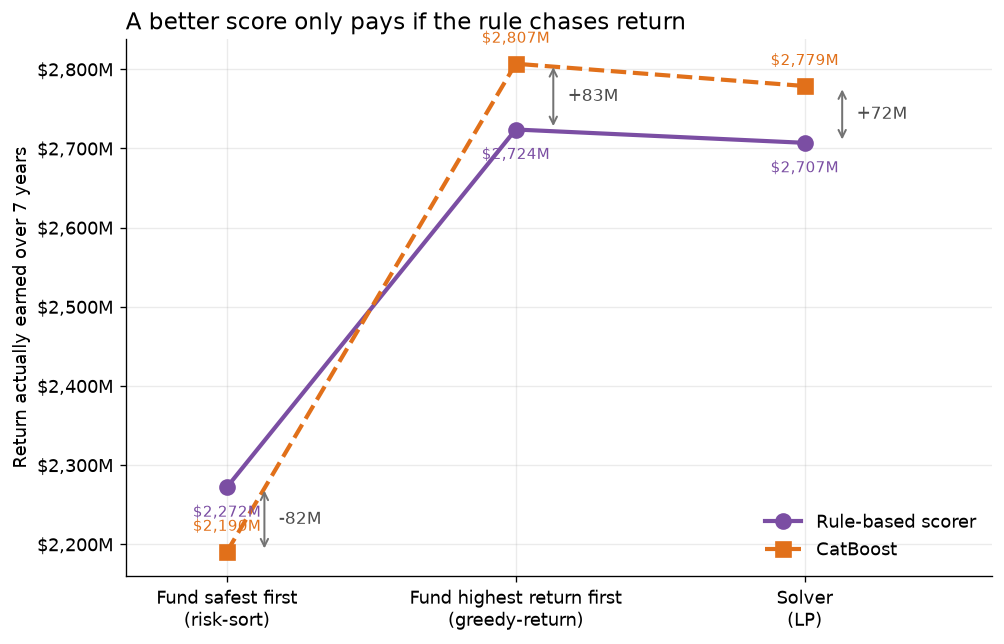

rule               rule-based     CatBoost    difference
--------------------------------------------------------
risk-sort            2,272.0M     2,190.4M        -81.5M
greedy-return        2,723.8M     2,806.9M        +83.1M
LP                   2,707.0M     2,778.8M        +71.8M


In [8]:
RULES = ["risk-sort", "greedy-return", "LP"]

# the summary stores "score / rule" strings; pull the six real returns out
real = {p["portfolio"]: p["real_M"] for p in port_summary["portfolios"]}
y_rule = [real[f"rule-based / {r}"] for r in RULES]
y_cat = [real[f"CatBoost / {r}"] for r in RULES]

x = np.arange(len(RULES))

fig, ax = plt.subplots(figsize=(8.5, 5.5))

ax.plot(x, y_rule, color=SCORE["rule"]["color"], ls=SCORE["rule"]["ls"],
        marker="o", lw=2.5, ms=9, label="Rule-based scorer")
ax.plot(x, y_cat, color=SCORE["cat"]["color"], ls=SCORE["cat"]["ls"],
        marker="s", lw=2.5, ms=9, label="CatBoost")

# label the gap at each rule
for i, r in enumerate(RULES):
    diff = y_cat[i] - y_rule[i]
    hi, lo = max(y_cat[i], y_rule[i]), min(y_cat[i], y_rule[i])
    ax.annotate("", xy=(i + 0.13, hi), xytext=(i + 0.13, lo),
                arrowprops=dict(arrowstyle="<->", color="0.45", lw=1.2))
    ax.text(i + 0.18, (hi + lo) / 2, f"{diff:+,.0f}M",
            va="center", fontsize=10, color="0.3")

for i in range(len(RULES)):
    ax.text(i, y_rule[i] - 22, f"${y_rule[i]:,.0f}M", ha="center",
            va="top", fontsize=9, color=SCORE["rule"]["color"])
    ax.text(i, y_cat[i] + 22, f"${y_cat[i]:,.0f}M", ha="center",
            va="bottom", fontsize=9, color=SCORE["cat"]["color"])

ax.set_xticks(x)
ax.set_xticklabels(["Fund safest first\n(risk-sort)",
                    "Fund highest return first\n(greedy-return)",
                    "Solver\n(LP)"])
ax.set_xlim(-0.35, len(RULES) - 0.35)
ax.set_ylabel("Return actually earned over 7 years")
ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"${v:,.0f}M"))
ax.set_title("A better score only pays if the rule chases return",
             loc="left", fontsize=14)
ax.legend(loc="lower right")

plt.tight_layout()
save(fig, "fig3_score_rule_interaction")
plt.show()

print(f"{'rule':16} {'rule-based':>12} {'CatBoost':>12} {'difference':>13}")
print("-" * 56)
for i, r in enumerate(RULES):
    print(f"{r:16} {y_rule[i]:>11,.1f}M {y_cat[i]:>11,.1f}M "
          f"{y_cat[i]-y_rule[i]:>+12,.1f}M")